In [50]:

import numpy as np
import pandas as pd 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/imdb-5000-movies-multiple-genres-dataset/IMDb_All_Genres_etf_clean1.csv


In [51]:
df=pd.read_csv('/kaggle/input/imdb-5000-movies-multiple-genres-dataset/IMDb_All_Genres_etf_clean1.csv')

In [52]:
df.head()

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre
0,Kantara,2022,Rishab Shetty,"Rishab Shetty, Sapthami Gowda, Kishore Kumar G...",9.3,148,UA,Gross Unkown,Action,"Adventure, Drama"
1,The Dark Knight,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.0,152,UA,$534.86M,Action,"Crime, Drama"
2,The Lord of the Rings: The Return of the King,2003,Peter Jackson,"Elijah Wood, Viggo Mortensen, Ian McKellen, Or...",9.0,201,U,$377.85M,Action,"Adventure, Drama"
3,Inception,2010,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,148,UA,$292.58M,Action,"Adventure, Sci-Fi"
4,The Lord of the Rings: The Two Towers,2002,Peter Jackson,"Elijah Wood, Ian McKellen, Viggo Mortensen, Or...",8.8,179,UA,$342.55M,Action,"Adventure, Drama"


In [53]:
# I want to check Total_Gross first.
# I can see the first value itself is unknown.
# I will how many null values are there.
# Additionally, I want to remove $ and M and convert them into numbers so I can use them for some calculation

In [54]:
df[df['Total_Gross']=='Gross Unkown']['Total_Gross'].value_counts()

Gross Unkown    861
Name: Total_Gross, dtype: int64

array([[<AxesSubplot:title={'center':'Year'}>]], dtype=object)

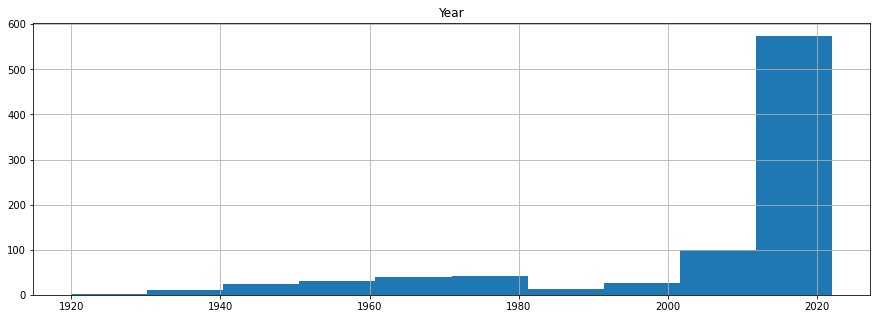

In [55]:
df[df['Total_Gross']=='Gross Unkown'].hist(column=['Year'], figsize=(15, 5))

In [56]:
df[df['Total_Gross']=='Gross Unkown']['Year'].value_counts()

2021    124
2020     92
2022     88
2019     77
2018     50
       ... 
1932      1
1935      1
1984      1
1986      1
1990      1
Name: Year, Length: 86, dtype: int64

In [57]:
# I can see 861 has gross not known. Most of them are newly released movies.
# The dataset needs Data quality checks.
# I may replace the unknown with some values (zero for now). I will decide later.
# For now, I will replace $ and M.

In [58]:
df['Total_Gross'].replace('Gross Unkown','0',inplace=True)
def Replacer(row):
    return row.replace('$','').replace('M','')

df['Total_Gross']=df['Total_Gross'].apply(Replacer)
df['Total_Gross']=df['Total_Gross'].astype(float)

In [59]:
df.head()

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre
0,Kantara,2022,Rishab Shetty,"Rishab Shetty, Sapthami Gowda, Kishore Kumar G...",9.3,148,UA,0.00,Action,"Adventure, Drama"
1,The Dark Knight,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.0,152,UA,534.86,Action,"Crime, Drama"
2,The Lord of the Rings: The Return of the King,2003,Peter Jackson,"Elijah Wood, Viggo Mortensen, Ian McKellen, Or...",9.0,201,U,377.85,Action,"Adventure, Drama"
3,Inception,2010,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,148,UA,292.58,Action,"Adventure, Sci-Fi"
4,The Lord of the Rings: The Two Towers,2002,Peter Jackson,"Elijah Wood, Ian McKellen, Viggo Mortensen, Or...",8.8,179,UA,342.55,Action,"Adventure, Drama"


In [60]:
df['Rating'].min(),df['Rating'].max()

(1.0, 9.3)

In [61]:
# I was looking at the Rating Column. The minimum is 1, and the maximum is 9.3.
# I will classify ratings into three categories (Good, Average and Bad).

In [62]:
def RatingCategory(row):
    return 'Good' if row>7 else 'Average' if row>4 and row<=7 else 'Bad'

df['Rating_category']=df['Rating'].apply(RatingCategory)

<AxesSubplot:xlabel='Year'>

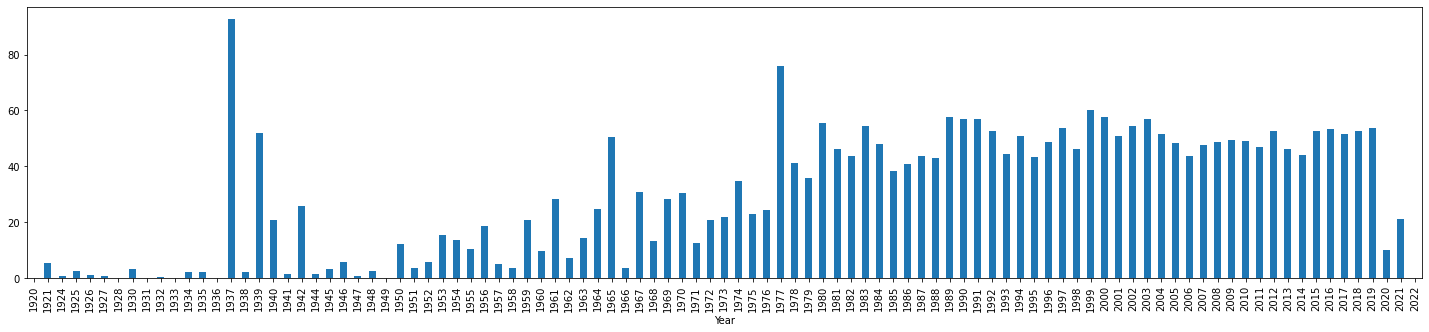

In [63]:
df.groupby(['Year'])['Total_Gross'].mean().plot( kind='bar',figsize=(25, 5))

In [64]:
df[df['Year']==1937]

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre,Rating_category
1995,Snow White and the Seven Dwarfs,1937,"Directors:William Cottrell, David Hand, Wilfre...","Adriana Caselotti, Harry Stockwell, Lucille La...",7.6,83,U,184.93,Animation,"Adventure, Family",Good
3566,La Grande Illusion,1937,Jean Renoir,"Jean Gabin, Dita Parlo, Pierre Fresnay, Erich ...",8.1,113,Not Rated,0.17,Drama,War,Good


In [65]:
# I saw 1937 has high peak. I knew something is wrong.
# I think mean is not a good choice.
# Mean of Movies after 1980 looking flat. Let's gather more details on that.

<AxesSubplot:xlabel='Year'>

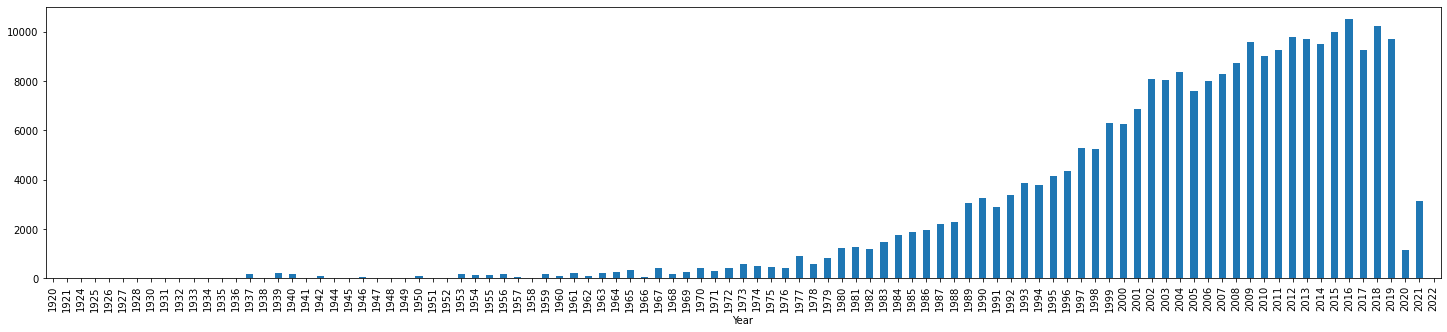

In [66]:
df.groupby(['Year'])['Total_Gross'].sum().plot( kind='bar',figsize=(25, 5))

In [67]:
def compound_interest(row):
    return  row[7] * (pow((1 + 3.7 / 100), row[11]))

df['Year_diff']=2023-df['Year']
df['Total_gross_inflation']=df.apply(compound_interest,axis=1)

<AxesSubplot:xlabel='Year'>

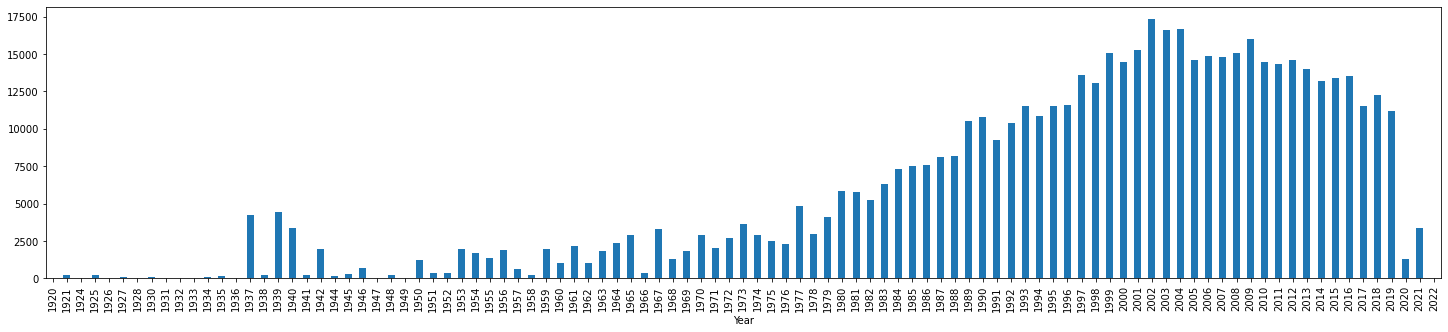

In [68]:
df.groupby(['Year'])['Total_gross_inflation'].sum().plot( kind='bar',figsize=(25, 5))

In [69]:
# I have adjusted the inflation in Total_Gross. I feel it is not fair to compare 1920 gross with today.
# I chose 3.7 as the inflation rate (Read on Google), Gross was given in dollars that's why I chose the US inflation rate.
# We can see some difference in both the graph but it's not that much. It means recent movies have earned more than old movies. I assume multiple reasons for that.
#    1. OTT Platform.
#    2. Number of theaters has increased.
#    3. Population has increased.
# As mentioned in previous comment. The mean is low for recent movies. I guess lots of flop movies have been released.

<AxesSubplot:xlabel='Year'>

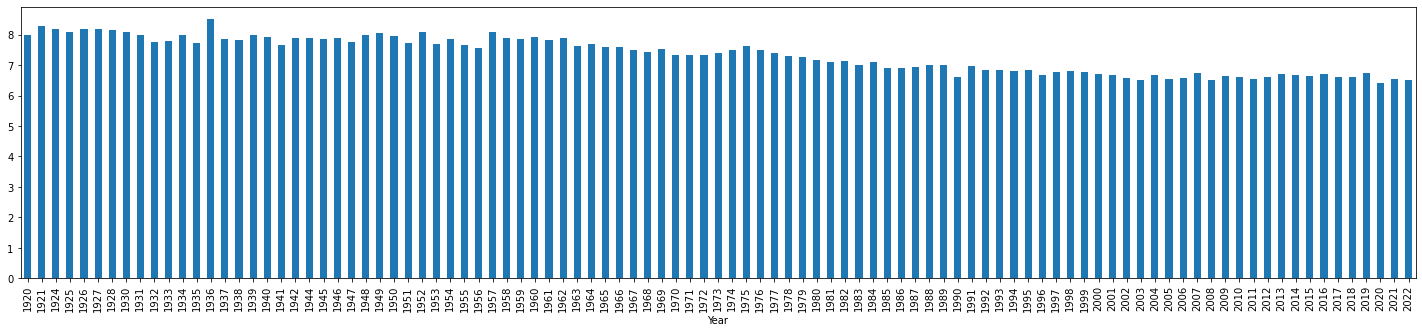

In [70]:
df.groupby(['Year'])['Rating'].mean().plot( kind='bar',figsize=(25, 5))

In [71]:
# Strange to see old movies has better rating than recent ones. I think because of fewer counts but still mean has fallen from 8 to 7.
# I first thought, High rated movies would have more gross but looking at the charts I don't think so that's True. Let's derive a Correlation.

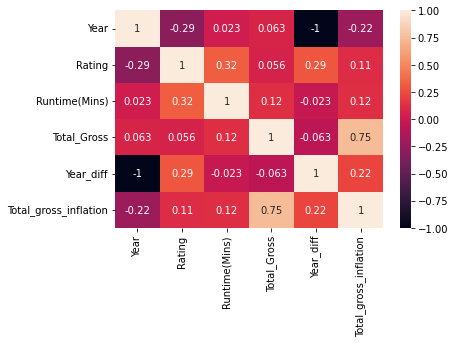

In [72]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [73]:
df.groupby(['Rating_category'])['Movie_Title'].count()

Rating_category
Average    3251
Bad          57
Good       2254
Name: Movie_Title, dtype: int64

In [74]:
df['Director_movies_counts']=df['Director'].map(df.groupby(['Director'])['Movie_Title'].count().to_dict())
df[df['Director_movies_counts']>5].groupby(['Director'])['Rating'].mean().nlargest(5)

Director
Charles Chaplin      8.333333
Sergio Leone         8.216667
Akira Kurosawa       8.200000
Christopher Nolan    8.154545
Stanley Kubrick      8.080000
Name: Rating, dtype: float64

In [75]:
df[df['Director_movies_counts']>5].groupby(['Director'])['Total_gross_inflation'].mean().nlargest(5)

Director
George Lucas                          828.771934
James Cameron                         672.493514
J.J. Abrams                           508.496181
Directors:Anthony Russo, Joe Russo    404.777138
Steven Spielberg                      360.266180
Name: Total_gross_inflation, dtype: float64

In [76]:
df[df['Director_movies_counts']>5].groupby(['Director'])['Total_Gross'].mean().nlargest(5)

Director
J.J. Abrams                           366.566667
Directors:Anthony Russo, Joe Russo    325.810000
James Cameron                         278.425714
George Lucas                          267.610000
Jon Favreau                           234.002500
Name: Total_Gross, dtype: float64

In [77]:
df[df['Director_movies_counts']>5].groupby(['Director'])['Runtime(Mins)'].sum().nlargest(5)

Director
Clint Eastwood      4017
Woody Allen         3888
Steven Spielberg    3881
Ron Howard          3065
Martin Scorsese     2991
Name: Runtime(Mins), dtype: int64

In [78]:
# Correlations among the attribute is very poor.
# Very few bad movies, most are average and good.
# I checked which director has given good-rated movies. I want it to be fair that's why given a condition director should have directed at least 5 movies.
# Similar way, If I compare Total gross and Total gross (inflation), I don't see much difference order of the top 5 is different only.
# High rated movies don't guarantee high gross. As we got in correlation.

In [79]:
from collections import Counter 

def TopCalulatorForMultiple(a):
    l=list()
    for i in df[a].dropna(): #We can drop null values because it will be unfair to replace it with sommeone else name
        for j in i.split(','):
            l.append(j.strip())
    d = Counter(l) 
    df_new=pd.DataFrame(d.items(), columns=['Actor', 'Movie Count'])
    return df_new.sort_values(by=['Movie Count'],ascending=False).head(5)


# Top 5 actor done most movies
TopCalulatorForMultiple('Actors')

,Actor,Movie Count
110,Robert De Niro,61
426,Tom Hanks,49
317,Samuel L. Jackson,48
623,Nicolas Cage,47
214,Johnny Depp,42


In [80]:
# Top 5 side genre in movies

TopCalulatorForMultiple('side_genre')

,Actor,Movie Count
1,Drama,2251
11,Comedy,915
13,Romance,883
6,Thriller,880
0,Adventure,860


<AxesSubplot:xlabel='main_genre', ylabel='count'>

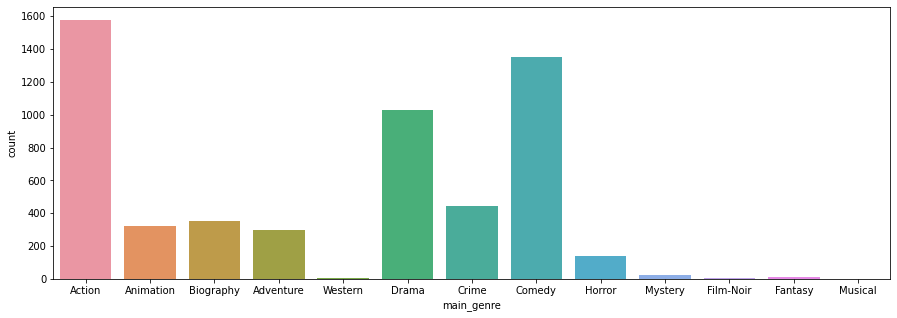

In [81]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.countplot(x = 'main_genre', data = df,ax=ax)

<AxesSubplot:xlabel='Censor'>

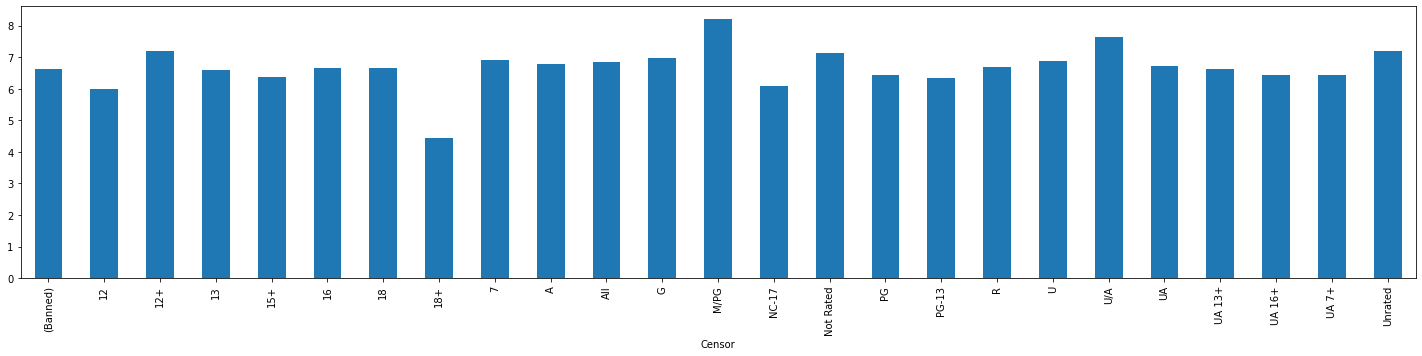

In [82]:
df.groupby(['Censor'])['Rating'].mean().plot( kind='bar',figsize=(25, 5))

In [83]:
# Drama is the 3rd most main genre and 1st most side genre. Same with Comedy 2nd main genre and 2nd most side genre.
# Only 18+ movies are less rated. Rest has similar ratings.